In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
train_transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
  transforms.ToTensor(),
  transforms.Normalize(
    [0.485, 0.456, 0.406],
    [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(
    [0.485, 0.456, 0.406],
    [0.229, 0.224, 0.225])
])

In [3]:
train_dir = "Dataset/Sugarcane Dataset Split/train"
val_dir = "Dataset/Sugarcane Dataset Split/valid"
test_dir = "Dataset/Sugarcane Dataset Split/test"

train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds = datasets.ImageFolder(val_dir, transform=val_transform)
test_ds = datasets.ImageFolder(test_dir, transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

In [4]:
def create_resnet50(num_classes):
  model = models.resnet50(weights="IMAGENET1K_V1")
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  return model.to(device)

model = create_resnet50(num_classes)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\tusha/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:23<00:00, 4.32MB/s]


In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
  optimizer, T_0=5, T_mult=2
)

In [6]:
history = {
  "train_loss": [], "val_loss": [],
  "train_acc": [], "val_acc": [],
  "train_prec": [], "val_prec": [],
  "train_rec": [], "val_rec": [],
  "train_f1": [], "val_f1": [],
}

In [7]:
def calculate_metrics(outputs, labels):
  preds = torch.argmax(outputs, dim=1).cpu().numpy()
  labels = labels.cpu().numpy()
  precision = precision_score(labels, preds, average='macro', zero_division=0)
  recall = recall_score(labels, preds, average='macro', zero_division=0)
  f1 = f1_score(labels, preds, average='macro', zero_division=0)
  accuracy = (preds == labels).sum() / len(labels)
  return accuracy, precision, recall, f1

In [8]:
#Training Function (AMP + Early Stopping)
scaler = torch.amp.GradScaler('cuda')
best_val_loss = float("inf")
early_stop_counter = 0
PATIENCE = 8

In [9]:
def train_one_epoch(history):
  model.train()
  running_loss = 0
  correct, total = 0, 0
  all_outputs, all_labels = [], []

  for images, labels in tqdm(train_loader, desc="Training", leave=False):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()

    with torch.amp.autocast('cuda'):
      outputs = model(images)
      loss = criterion(outputs, labels)

    scaler.scale(loss).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
    scaler.step(optimizer)
    scaler.update()

    running_loss += loss.item()
    preds = outputs.argmax(1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)

    all_outputs.append(outputs.detach())
    all_labels.append(labels.detach())
  
  outputs_cat = torch.cat(all_outputs)
  labels_cat = torch.cat(all_labels)
  acc, prec, rec, f1 = calculate_metrics(outputs_cat, labels_cat)
  
  history["train_loss"].append(running_loss / len(train_loader))
  history["train_acc"].append(acc)
  history["train_prec"].append(prec)
  history["train_rec"].append(rec)
  history["train_f1"].append(f1)

  return history

In [10]:
def validate(history):
  model.eval()
  running_loss = 0
  correct, total = 0, 0
  val_outputs, val_labels = [], []

  with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Validating", leave=False):
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)

      running_loss += loss.item()
      preds = outputs.argmax(1)
      correct += (preds == labels).sum().item()
      total += labels.size(0)

      val_outputs.append(outputs)
      val_labels.append(labels)
    
    outputs_cat = torch.cat(val_outputs)
    labels_cat = torch.cat(val_labels)
    acc, prec, rec, f1 = calculate_metrics(outputs_cat, labels_cat)
    
    history["val_loss"].append(running_loss / len(val_loader))
    history["val_acc"].append(acc)
    history["val_prec"].append(prec)
    history["val_rec"].append(rec)
    history["val_f1"].append(f1)

  return history

Training loop:

In [11]:
EPOCHS = 50

for epoch in range(EPOCHS):
  print(f"\nEpoch {epoch+1}/{EPOCHS}")

  history = train_one_epoch(history)
  history = validate(history)
  scheduler.step(epoch)

  print(f"Train Loss: {history['train_loss'][-1]:.4f} | Train Acc: {history['train_acc'][-1]:.4f}")
  print(f"Val Loss:   {history['val_loss'][-1]:.4f} | Val Acc:   {history['val_acc'][-1]:.4f}")

  # Early stopping
  if history["val_loss"][-1] < best_val_loss:
    best_val_loss = history["val_loss"][-1]
    early_stop_counter = 0
    torch.save(model.state_dict(), "Models/resnet50.pth")
    print("Model saved!")
  else:
    early_stop_counter += 1

  if early_stop_counter >= PATIENCE:
    print("Early stopping triggered!")
    break


Epoch 1/50


Train Loss: 0.9741 | Train Acc: 0.8283
Val Loss:   0.6896 | Val Acc:   0.9514
Model saved!

Epoch 2/50


Train Loss: 0.7308 | Train Acc: 0.9257
Val Loss:   0.6759 | Val Acc:   0.9476
Model saved!

Epoch 3/50


Train Loss: 0.6818 | Train Acc: 0.9425
Val Loss:   0.6191 | Val Acc:   0.9632
Model saved!

Epoch 4/50


Train Loss: 0.6376 | Train Acc: 0.9556
Val Loss:   0.5945 | Val Acc:   0.9740
Model saved!

Epoch 5/50


...

Train Loss: 0.5733 | Train Acc: 0.9748
Val Loss:   0.5683 | Val Acc:   0.9753

Epoch 21/50


Train Loss: 0.5704 | Train Acc: 0.9750
Val Loss:   0.5714 | Val Acc:   0.9753

Epoch 22/50


Train Loss: 0.5691 | Train Acc: 0.9765
Val Loss:   0.5752 | Val Acc:   0.9750

Epoch 23/50


Train Loss: 0.5700 | Train Acc: 0.9753
Val Loss:   0.5797 | Val Acc:   0.9750

Epoch 24/50


Train Loss: 0.5675 | Train Acc: 0.9767
Val Loss:   0.5833 | Val Acc:   0.9715
Early stopping triggered!


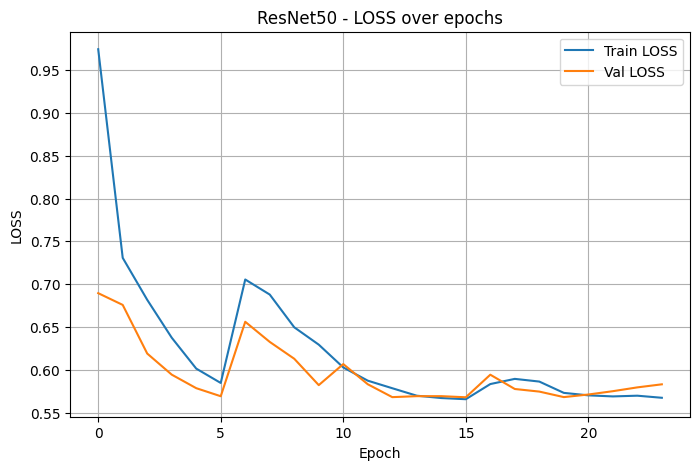

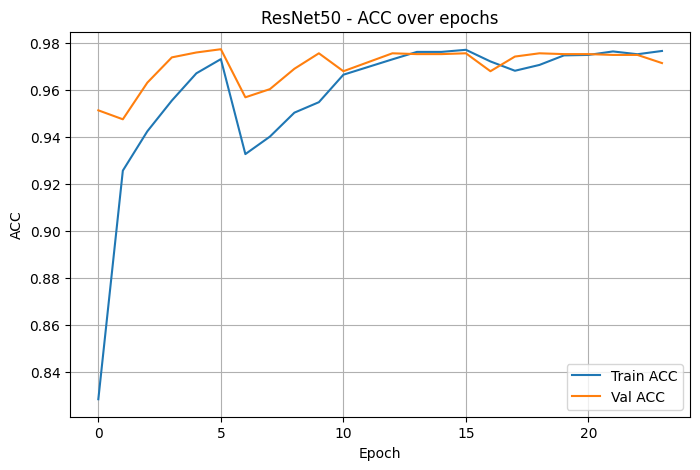

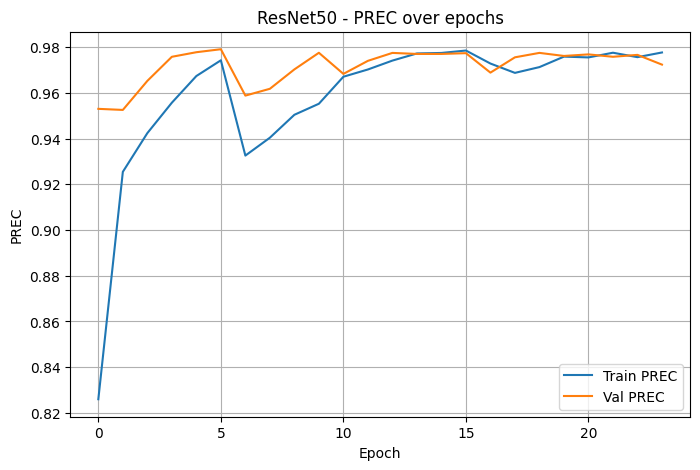

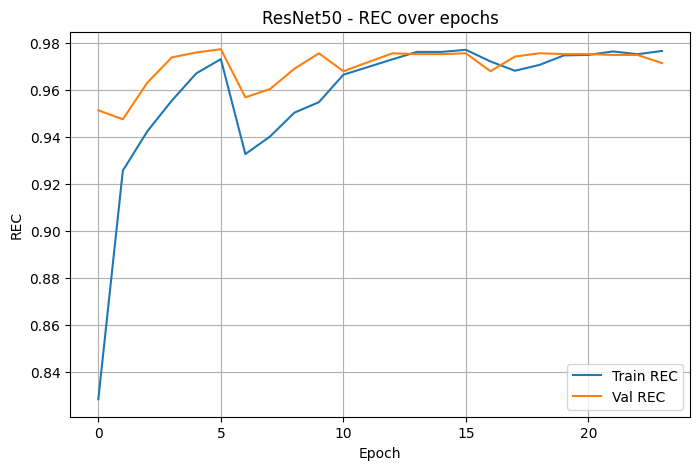

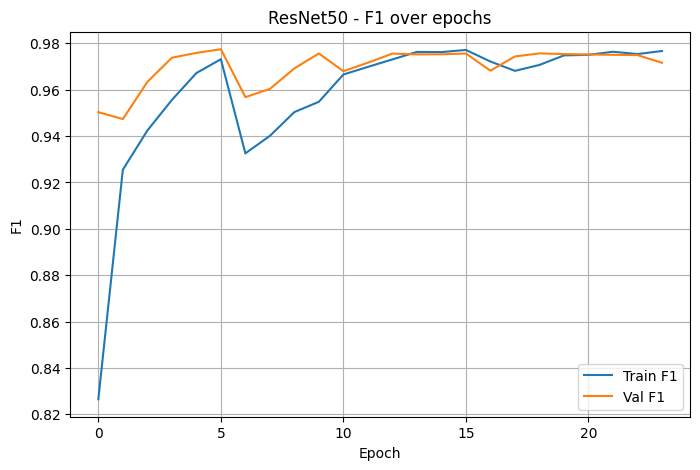

In [12]:
def plot_history(history):
  metrics = ['loss', 'acc', 'prec', 'rec', 'f1']
  for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.plot(history[f"train_{metric}"], label=f"Train {metric.upper()}")
    plt.plot(history[f"val_{metric}"], label=f"Val {metric.upper()}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.title(f"ResNet50 - {metric.upper()} over epochs")
    plt.legend()
    plt.grid(True)

    if metric == 'loss':
      plt.savefig(
        "ResNet50_loss_vs_epoch.png",
        dpi=1000,
        bbox_inches="tight"
      )

    plt.show()

plot_history(history)

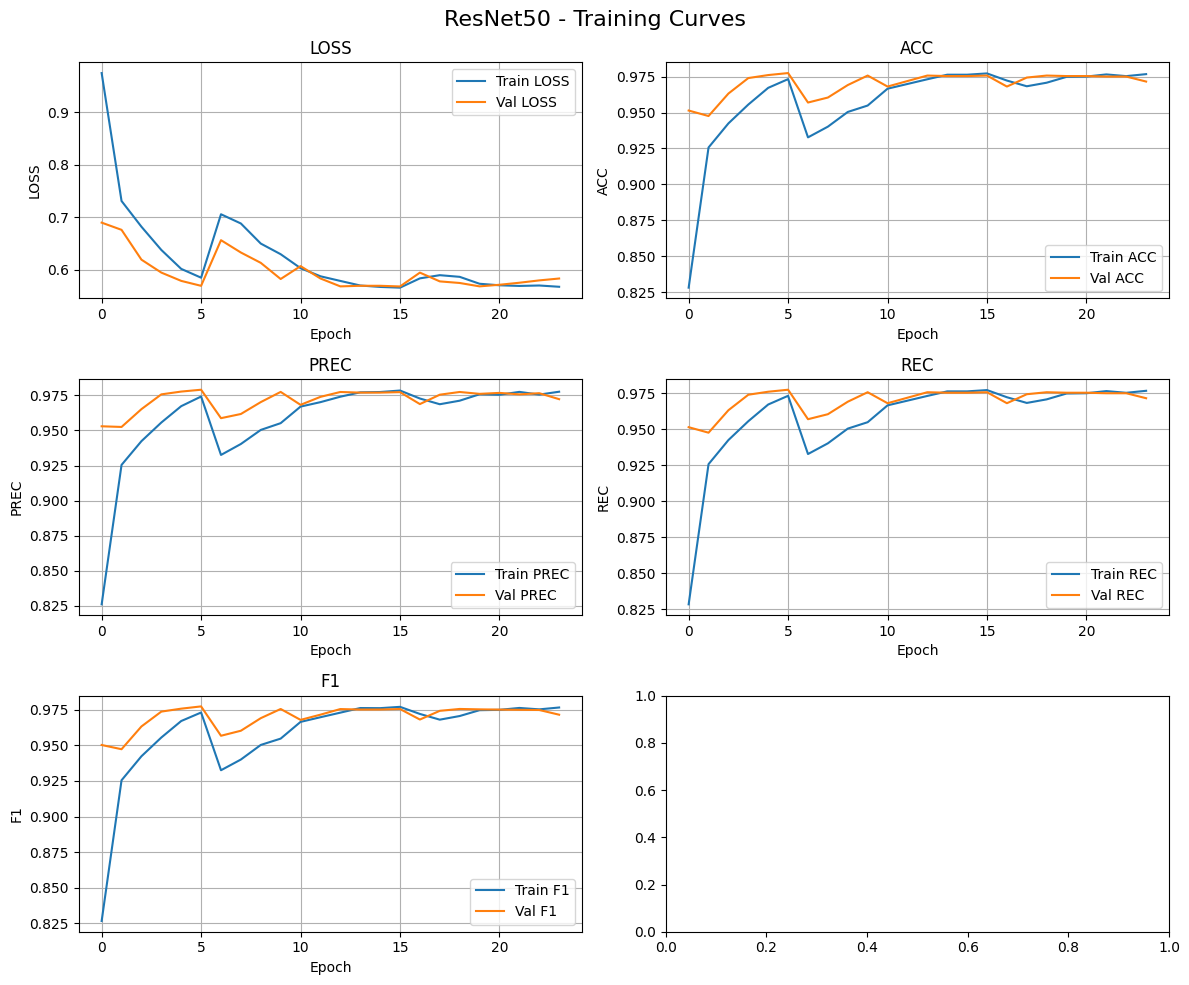

In [13]:
def plot_history_multi(history):
  metrics = ['loss', 'acc', 'prec', 'rec', 'f1']
  fig, axes = plt.subplots(3, 2, figsize=(12, 10))
  axes = axes.ravel()

  for i, metric in enumerate(metrics):
    axes[i].plot(history[f"train_{metric}"], label=f"Train {metric.upper()}")
    axes[i].plot(history[f"val_{metric}"], label=f"Val {metric.upper()}")
    axes[i].set_title(metric.upper())
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel(metric.upper())
    axes[i].grid(True)
    axes[i].legend()

  plt.suptitle(f"ResNet50 - Training Curves", fontsize=16)
  plt.tight_layout()
  plt.show()

plot_history_multi(history)

Evaluation:

In [14]:
model.load_state_dict(torch.load("Models/resnet50.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    preds = outputs.argmax(1).cpu().numpy()

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification report:
                  precision    recall  f1-score   support

Banded Chlorosis       0.94      0.87      0.90       120
      Brown Rust       0.88      0.99      0.93       120
      Brown Spot       0.99      0.97      0.98       120
    Dried Leaves       0.98      1.00      0.99       120
    Grassy Shoot       1.00      1.00      1.00       120
  Healthy Leaves       0.96      1.00      0.98       120
   Insect Damage       1.00      1.00      1.00       120
    Pokkah Boeng       1.00      1.00      1.00       120
        Sett Rot       1.00      1.00      1.00       120
            Smut       1.00      1.00      1.00       120
   Viral Disease       0.98      0.93      0.95       120
     Yellow Leaf       0.99      0.96      0.97       120

        accuracy                           0.98      1440
       macro avg       0.98      0.98      0.98      1440
    weighted avg       0.98      0.98      0.98      1440



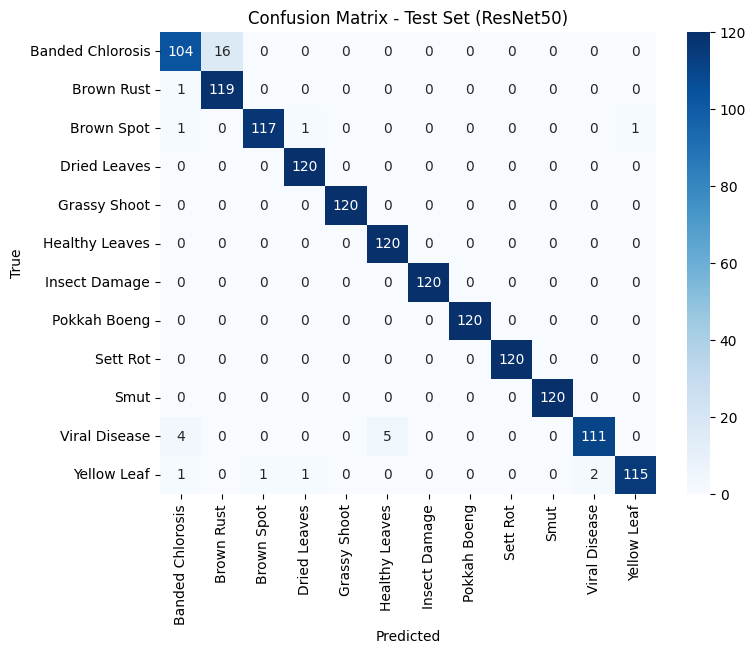

In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Test Set (ResNet50)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig(
"ResNet50_Test_set_confusion_matrix.png",
dpi=1000,
bbox_inches="tight"
)

plt.show()

In [16]:
def compute_test_metrics(y_true, y_pred):
  test_acc  = accuracy_score(y_true, y_pred)
  test_prec = precision_score(y_true, y_pred, average="macro")
  test_rec  = recall_score(y_true, y_pred, average="macro")
  test_f1   = f1_score(y_true, y_pred, average="macro")

  return test_acc, test_prec, test_rec, test_f1

In [17]:
metrics = ["test_acc", "test_prec", "test_rec", "test_f1"]
history.update(dict(zip(metrics, compute_test_metrics(y_true, y_pred))))

In [18]:
def plot_joint_bar(history):
  metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

  train_vals = [
    history["train_acc"][-1],
    history["train_prec"][-1],
    history["train_rec"][-1],
    history["train_f1"][-1]
  ]

  val_vals = [
    history["val_acc"][-1],
    history["val_prec"][-1],
    history["val_rec"][-1],
    history["val_f1"][-1]
  ]

  test_vals = [
    history["test_acc"],
    history["test_prec"],
    history["test_rec"],
    history["test_f1"]
  ]

  x = np.arange(len(metrics))
  width = 0.25

  plt.figure(figsize=(12, 6))

  bars_train = plt.bar(x - width, train_vals, width, label="Train")
  bars_val   = plt.bar(x, val_vals, width, label="Validation")
  bars_test  = plt.bar(x + width, test_vals, width, label="Test")

  #labelling bars with their respective metric values
  def add_labels(bars):
    for bar in bars:
      height = bar.get_height()
      plt.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        rotation=90,
        fontsize=14
      )

  add_labels(bars_train)
  add_labels(bars_val)
  add_labels(bars_test)

  plt.xticks(x, metrics, fontsize=12)
  plt.ylabel("Score", fontsize=12)
  plt.title("ResNet50 - Train vs Validation vs Test Metrics", fontsize=14)
  plt.legend(loc='best')
  plt.ylim(0, 1.2)

  plt.show()

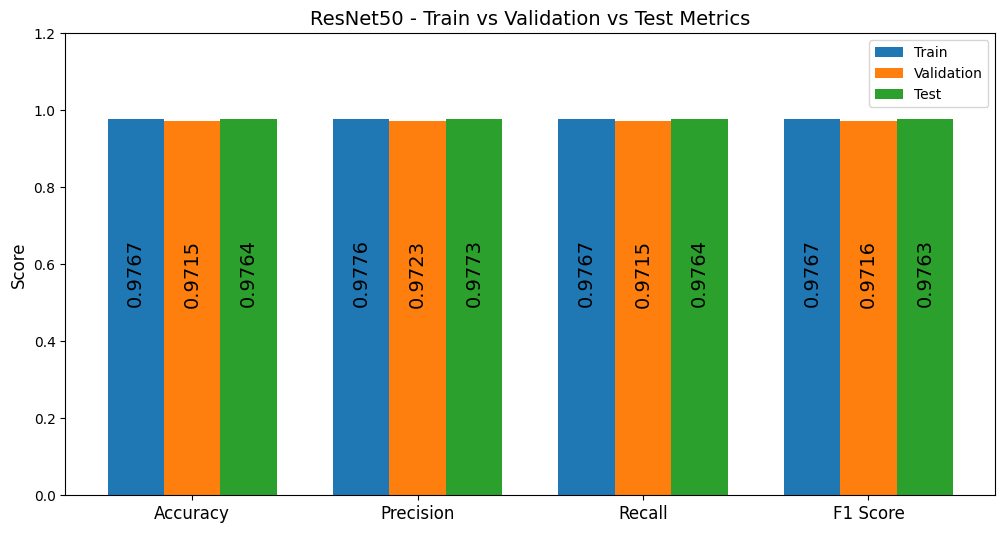

In [19]:
plot_joint_bar(history)